In [27]:
from torchvision.datasets import MNIST
from torchvision import transforms
from torch.utils.data import DataLoader, Dataset
import torch
import numpy as np
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from matplotlib import pyplot as plt


device = "cuda" if torch.cuda.is_available() else "cpu"

img_transform = transforms.Compose(
    [
        transforms.ToTensor(),
        transforms.Normalize((0.5),(0.5)),
        transforms.Lambda(lambda x: x.to(device))
    ]
)

batch_size = 512
trn_ds = MNIST('', train=True, download=True, transform=img_transform)
val_ds = MNIST('', train=False, download=True, transform=img_transform)
trn_dl = DataLoader(trn_ds, batch_size=batch_size, shuffle=True)
val_dl = DataLoader(val_ds, batch_size=batch_size)


In [28]:
class ConvAutoEncoder(nn.Module):
    def __init__(self):
        super().__init__()
        
        self.encoder = nn.Sequential(
            nn.Conv2d(1 ,32, 3, stride=3, padding=1), nn.ReLU(True),
            nn.MaxPool2d(2, stride=2),
            nn.Conv2d(32, 64, 3, stride=2, padding=1), nn.ReLU(True),
            nn.MaxPool2d(2, stride=1)
        )
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(64, 32, 3, stride=2), nn.ReLU(True),
            nn.ConvTranspose2d(32, 16, 5, stride=3, padding=1), nn.ReLU(True),
            nn.ConvTranspose2d(16, 1, 2, stride=2, padding=1), nn.Tanh(),
        )
        
    def forward(self, x):
        x = self.encoder(x)
        x = self.decoder(x)
        return x

In [29]:
from torchsummary import summary
model = ConvAutoEncoder().to(device)
summary(model, (1, 28, 28))


----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1           [-1, 32, 10, 10]             320
              ReLU-2           [-1, 32, 10, 10]               0
         MaxPool2d-3             [-1, 32, 5, 5]               0
            Conv2d-4             [-1, 64, 3, 3]          18,496
              ReLU-5             [-1, 64, 3, 3]               0
         MaxPool2d-6             [-1, 64, 2, 2]               0
   ConvTranspose2d-7             [-1, 32, 5, 5]          18,464
              ReLU-8             [-1, 32, 5, 5]               0
   ConvTranspose2d-9           [-1, 16, 15, 15]          12,816
             ReLU-10           [-1, 16, 15, 15]               0
  ConvTranspose2d-11            [-1, 1, 28, 28]              65
             Tanh-12            [-1, 1, 28, 28]               0
Total params: 50,161
Trainable params: 50,161
Non-trainable params: 0
---------------------------------

In [30]:
def train(model, trn_dl, criterion, optimizer):
    print("Training...")
    model.train()
    running_loss = 0.0
    for idx, (imgs, targets) in enumerate(trn_dl):
        outputs = model(imgs)
        loss = criterion(outputs, imgs)
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item() * imgs.size(0)
    epoch_loss = running_loss / len(trn_dl.dataset)
    return epoch_loss

def val(model ,val_dl, criterion):
    model.eval()
    running_loss = 0.0
    with torch.no_grad():
        for idx, (imgs, targets) in enumerate(val_dl):
            outputs = model(imgs)
            loss = criterion(outputs, imgs)
            running_loss += loss.item() * imgs.size(0)
    epoch_loss = running_loss / len(val_dl.dataset)
    return epoch_loss

Training...
Epoch [1/20], Train Loss: 0.3918, Val Loss: 0.2541
Training...
Epoch [2/20], Train Loss: 0.2037, Val Loss: 0.1543
Training...
Epoch [3/20], Train Loss: 0.1327, Val Loss: 0.1123
Training...
Epoch [4/20], Train Loss: 0.1047, Val Loss: 0.0940
Training...
Epoch [5/20], Train Loss: 0.0913, Val Loss: 0.0848
Training...
Epoch [6/20], Train Loss: 0.0834, Val Loss: 0.0782
Training...
Epoch [7/20], Train Loss: 0.0777, Val Loss: 0.0739
Training...
Epoch [8/20], Train Loss: 0.0736, Val Loss: 0.0697
Training...
Epoch [9/20], Train Loss: 0.0703, Val Loss: 0.0674
Training...
Epoch [10/20], Train Loss: 0.0676, Val Loss: 0.0646
Training...
Epoch [11/20], Train Loss: 0.0656, Val Loss: 0.0628
Training...
Epoch [12/20], Train Loss: 0.0637, Val Loss: 0.0614
Training...
Epoch [13/20], Train Loss: 0.0620, Val Loss: 0.0596
Training...
Epoch [14/20], Train Loss: 0.0605, Val Loss: 0.0597
Training...
Epoch [15/20], Train Loss: 0.0592, Val Loss: 0.0572
Training...
Epoch [16/20], Train Loss: 0.0580, Va

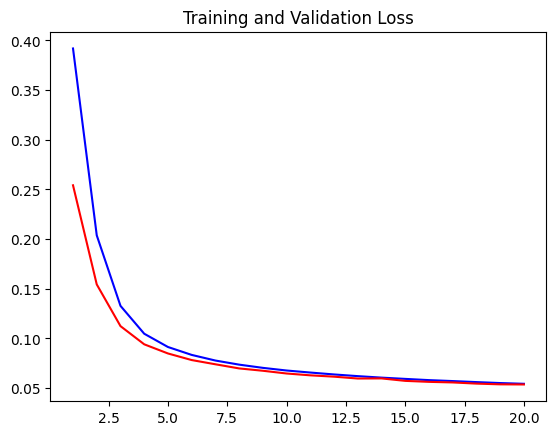

In [31]:
model = ConvAutoEncoder().to(device)
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-5)

num_epochs = 20
train_losses = []
val_losses = []
for epoch in range(num_epochs):
    trn_loss = train(model, trn_dl, criterion, optimizer)
    val_loss = val(model, val_dl, criterion)
    
    train_losses.append(trn_loss)
    val_losses.append(val_loss)
    
    print(f'Epoch [{epoch+1}/{num_epochs}], Train Loss: {trn_loss:.4f}, Val Loss: {val_loss:.4f}')

epochs = range(1, num_epochs + 1)
plt.plot(epochs, train_losses, 'b', label='Training loss')
plt.plot(epochs, val_losses, 'r', label='Validation loss')
plt.title('Training and Validation Loss')
plt.show()